### Colab Activity 20.3: Gradient Boosting

**Expected Time = 60 minutes**


This activity focuses on using the Gradient Boosting models in Scikit-Learn.  A dataset similar to the lecture example is created for the regression problem.  For classification, the same fetal health dataset from the earlier parts of the module is used.  

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score,confusion_matrix

In [4]:
def f(x):
    '''
    Small example regression dataset.
    '''
    np.random.seed(42)
    return np.sin(x**2) + np.random.normal(size = len(x), scale = 0.1)

In [29]:
x = np.linspace(0, 3, 20)
y = f(x)

In [30]:
X = x.reshape(-1, 1) #Make it 2D for sklearn

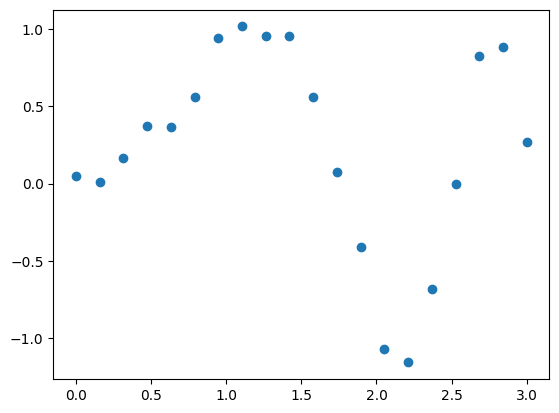

In [31]:
plt.scatter(x, y)

[Back to top](#-Index)

### Problem 1

#### Gradient Boosted Regressor


Use the `GradientBoostingRegressor` to create a model with default parameters `reg` and fit the model on `X` and `y`.  Assign the predictions as an array to `reg_pred`.  Uncomment the code to visualize the results.

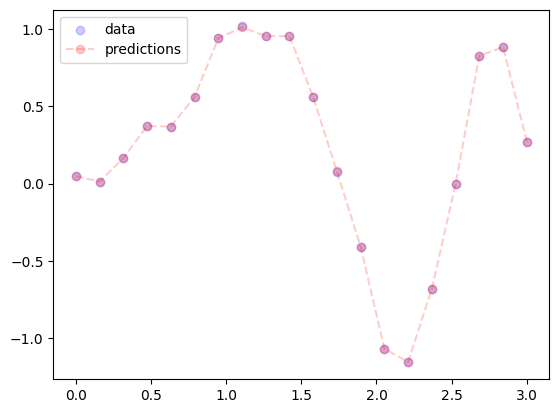

In [32]:
reg = GradientBoostingRegressor()
reg.fit(X,y)
reg_pred = reg.predict(X)


### ANSWER CHECK
plt.scatter(x, y, color = 'blue', alpha = 0.2, label = 'data')
plt.plot(x, reg_pred, '--ro', alpha = 0.2, label = 'predictions')
plt.legend();

[Back to top](#-Index)

### Problem 2

#### Gradient Boosting Classifier



The data for classification is again loaded and prepared below.  Use this to create a `GradientBoostingClassifier` with `random_state=0` named `clf` and fit this on the training data.  Score the accuracy of the model as `boost_acc` below.


In [33]:
df = pd.read_csv('/content/sample_data/fetal_health.csv')
X = df.drop('fetal_health', axis = 1).values
y = df['fetal_health']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [36]:
clf = GradientBoostingClassifier(random_state=0)
clf.fit(X_train, y_train)
boost_acc =  accuracy_score(y_test, clf.predict(X_test))

### ANSWER CHECK
print(boost_acc)#0.9511278195488722


0.9492481203007519


[Back to top](#-Index)

### Problem 3

#### Evaluating the Model



Create a confusion matrix for the boosted model on the test data.  Which label was best predicted?  Enter your answer as an integer to `ans3` below -- 1, 2, or 3.  

In [42]:
confusion_matrix( y_test, clf.predict(X_test))

array([[402,   9,   2],
       [ 14,  68,   0],
       [  2,   0,  35]])

In [43]:
y_test.value_counts()

,count
fetal_health,
1.0,413
2.0,82
3.0,37


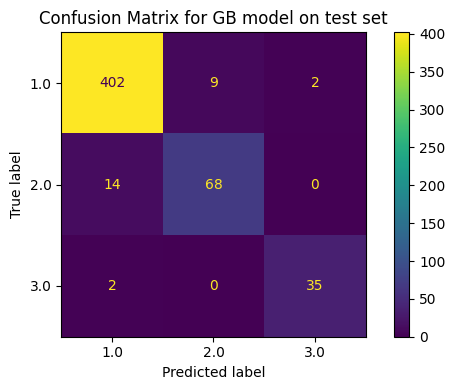

In [39]:
#Create plot
fig, ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, ax = ax)
ax.set_title("Confusion Matrix for GB model on test set")
plt.tight_layout()
plt.show()

In [44]:
ans3 = 1 # since 402/413 = 0.97 which is the highest correct predictions amoongs classes

### ANSWER CHECK
print(type(ans3))
print(ans3)

<class 'int'>
1
